Projet Maths For Data Sciences : AROKEUM NOé M1 IDD 

PARTIE 1 Linear programming relaxation

QUESTION 1 : ON DETERMINE LE PROGRAMME LINEAIRE 

ENSEMBLE UTILE .
G l'ensemble des groupes existants : G = {P,M,T,S,O}

Bu l'ensemble des bureaux Bu : {A1,A2,B1,B2,B3,C1,C2,D1,D2,D3,E1,E2}

Les ailes du batiment A={A1,A2} B={B1,B2,B3} C={C1,C2} D={D1,D2,D3} E={E1,E2}

LES VARIABLES UTILISEES

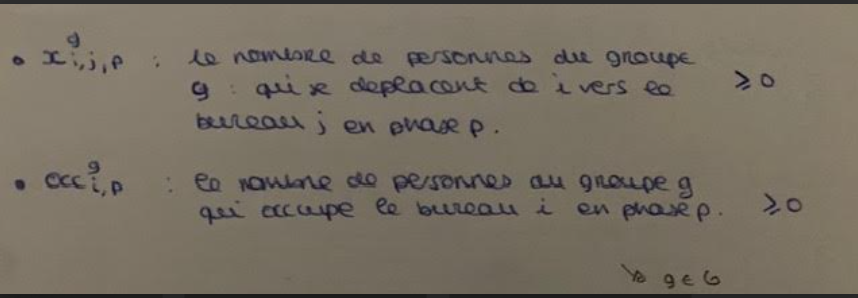

LA FONCTION OBJECTIF 

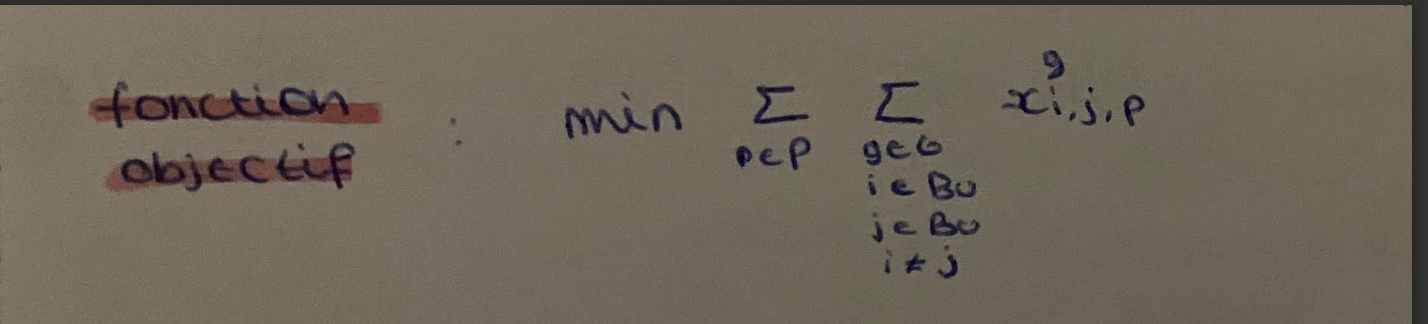

ICI on cherche a minimiser les déplacements totals : donc a chaque phase le nombre et utilisée pour la fonction objectif 

LES CONTRAINTES 

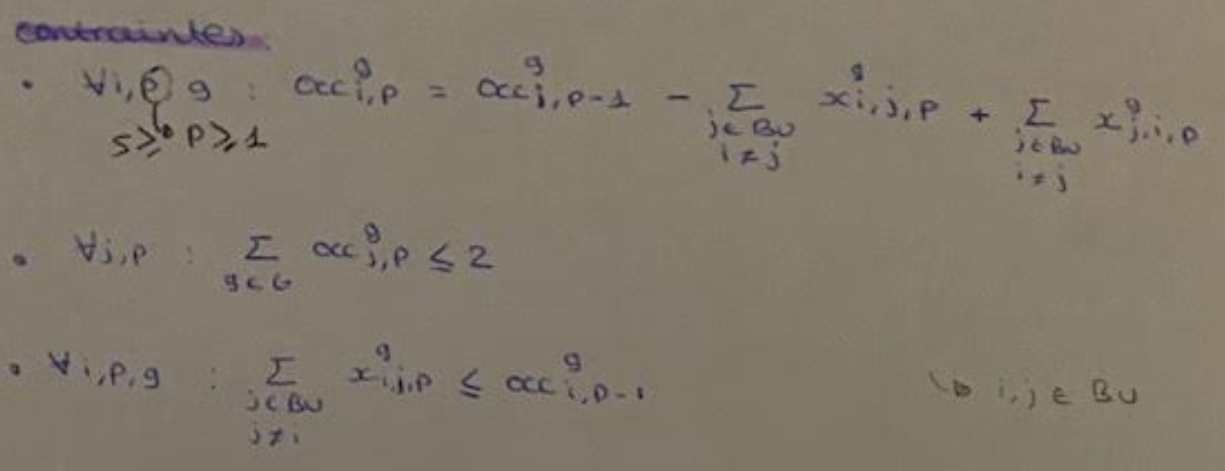

la premiere contraintes lie le nombre d'occupants dans un bureau, au deplacement au cours d'une phase 

la deuxieme : chaque bureau dois avoir un maximum de deux occupants

la troisieme : le nombre de personnes qui peuvent quitter un bureau ne peut pas etre supérieur (>) au nombre de personnes dans le bureau

CONTRAINTES LIEES A LA RENOVATION DE CHAQUES AILES

ici : on essaie d'exprimer le fait que une ailek  se toruve fermée pendant un phase p 

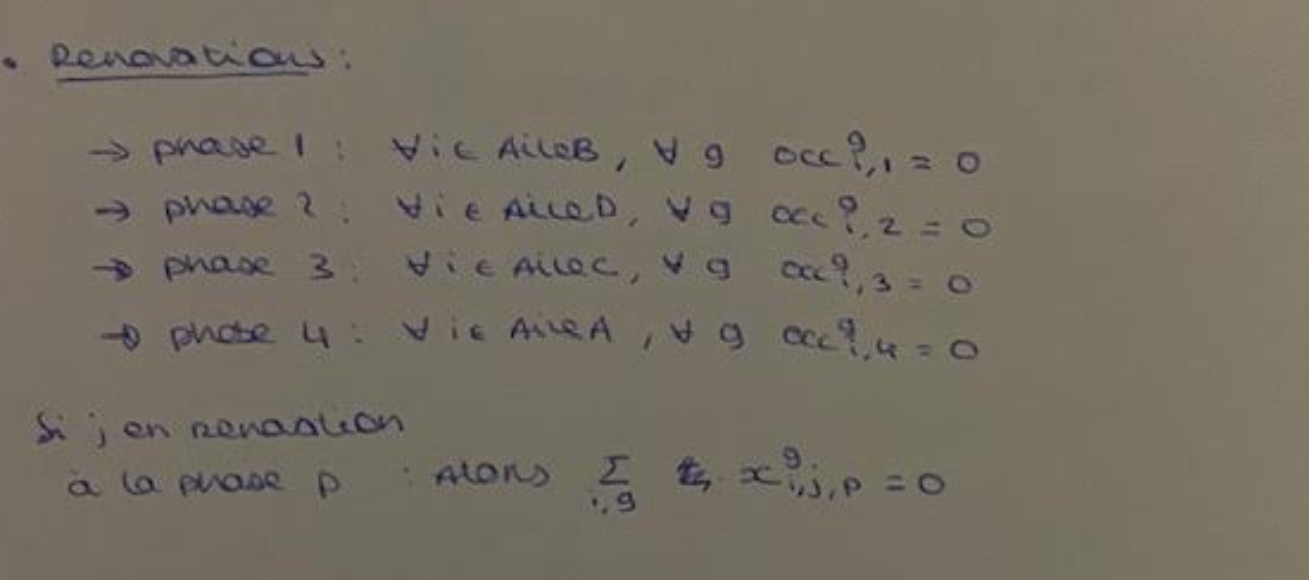

Contraintes liées au placement initial et final (comme sur les schémas de l'enoncé)

occupation d'un bureau i , en phase zero : comme sur l'enoncée : exemple 2 S en B2 en phase zéro 

occupation d'un bureau i , en phase cinq : comme sur le deuxiéme schéma : exemple 2 T en D2

LA KKT CONDITION (suite question 1)

les multiplicateurs

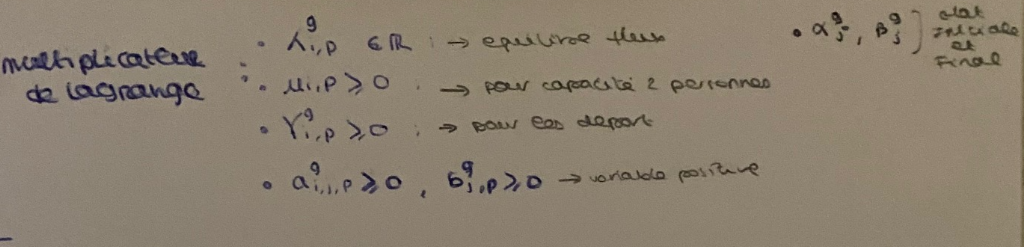

CONTRAINTES

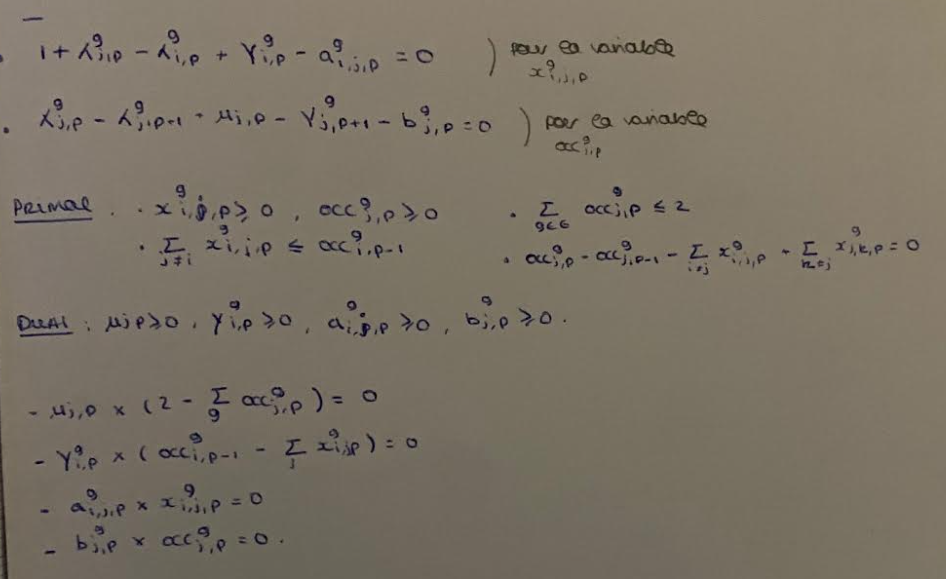

QUESTION 2 ON DETERMINE LA SOLUTION DU PROBLEME ET DU DUAL 

Pour cela on utilise un code python : la bibliotheque pulp 

on reecrit le LP sur le programme python 

In [3]:
import pulp

On definit les ensembles de base 

In [4]:
offices = [
    'A1', 'A2', 
    'B1', 'B2', 'B3', 
    'C1', 'C2', 
    'D1', 'D2', 'D3', 
    'E1', 'E2'
]

wings = {
    'A': ['A1', 'A2'],
    'B': ['B1', 'B2', 'B3'],
    'C': ['C1', 'C2'],
    'D': ['D1', 'D2', 'D3'],
    'E': ['E1', 'E2']
}

groups = ['M', 'P', 'O', 'T', 'S']
phases = [1, 2, 3, 4, 5] 

renovation_schedule = {
    1: 'B',
    2: 'D',
    3: 'C',
    4: 'A',
    5: None 
}

# POur les données initiales de l'enoncé 
initial_occ = {o: {g: 0 for g in groups} for o in offices}
initial_occ['A1']['P'] = 2
initial_occ['A2']['P'] = 2
initial_occ['B1']['O'] = 1; initial_occ['B1']['M'] = 1
initial_occ['B2']['S'] = 2
initial_occ['B3']['O'] = 1; initial_occ['B3']['T'] = 1
initial_occ['C1']['T'] = 2
initial_occ['C2']['S'] = 2
initial_occ['D1']['T'] = 1
initial_occ['D2']['M'] = 1
initial_occ['D3']['M'] = 2


# Pour la phase final 

target_occ = {o: {g: 0 for g in groups} for o in offices}
target_occ['A1']['P'] = 2; target_occ['A2']['P'] = 2
target_occ['B1']['M'] = 1; target_occ['B2']['M'] = 2; target_occ['B3']['M'] = 1
target_occ['C1']['S'] = 2; target_occ['C2']['S'] = 2
target_occ['D1']['T'] = 1; target_occ['D2']['T'] = 2; target_occ['D3']['T'] = 1
target_occ['E1']['O'] = 1; target_occ['E2']['O'] = 1

On crée le lp 

In [ ]:
#ON Crée le LP 
prob = pulp.LpProblem("Office_Relocation_Min_Moves", pulp.LpMinimize)


# On définit les variabes 
#ici la variable x^g: i,j,p 
move_vars = {}
for p in phases:
    for g in groups:
        for i in offices:
            for j in offices:
                if i != j:
                    move_vars[(p, g, i, j)] = pulp.LpVariable(f"x_{p}_{g}_{i}_{j}", 0, None, pulp.LpContinuous)


#ici on définit la variable occ^g :i,p
occ_vars = {}
all_phases_inc_0 = [0] + phases 

for p in all_phases_inc_0:
    for g in groups:
        for j in offices:
            occ_vars[(p, g, j)] = pulp.LpVariable(f"occ_{p}_{g}_{j}", 0, 2, pulp.LpContinuous)



#FONCTION BUT 
prob += pulp.lpSum([move_vars[(p, g, i, j)] for p, g, i, j in move_vars]) #but minimiser les deplacement 



# Etat initiale 
for g in groups:
    for j in offices:
        prob += occ_vars[(0, g, j)] == initial_occ[j][g], f"Init_Phase0_{j}_{g}"

# 
for p in phases:
    # contrainte 1 Occupants en P = Occupants en P-1 - Départs + Arrivées
    for g in groups:
        for j in offices:
            inflow = pulp.lpSum([move_vars[(p, g, i, j)] for i in offices if i != j])
            outflow = pulp.lpSum([move_vars[(p, g, j, k)] for k in offices if k != j])
            prob += occ_vars[(p, g, j)] == occ_vars[(p-1, g, j)] - outflow + inflow, f"Flow_{p}_{j}_{g}"

    # contraintes 2 :  deux personnes par bureau max 
    for j in offices:
        prob += pulp.lpSum([occ_vars[(p, g, j)] for g in groups]) <= 2, f"Cap_{p}_{j}"

    # contrainte 3 :  On ne peut pas déplacer plus de gens qu'il n'y en a 
    for g in groups:
        for i in offices:
            total_leaving_i = pulp.lpSum([move_vars[(p, g, i, j)] for j in offices if j != i])
            prob += total_leaving_i <= occ_vars[(p-1, g, i)], f"LimitMove_{p}_{i}_{g}"

    # Les Rénovations 
    wing_closed = renovation_schedule[p]
    if wing_closed:
        closed_offices = wings[wing_closed]
        for j in closed_offices:
            # Le bureau en renovation doit être vide à la fin de la phase
            for g in groups:
                prob += occ_vars[(p, g, j)] == 0, f"Reno_Closed_{p}_{j}_{g}"
            
            #on interdit les mouvements VERS un bureau en rénovation
            for g in groups:
                for i in offices:
                    if i != j:
                         prob += move_vars[(p, g, i, j)] == 0, f"No_Entry_Reno_{p}_{i}_{j}_{g}"
                         
# Etat final 
for g in groups:
    for j in offices:
        prob += occ_vars[(5, g, j)] == target_occ[j][g], f"Target_Phase5_{j}_{g}"
        

résolution

In [6]:
status = prob.solve()

print("Status:", pulp.LpStatus[status])
print("Total deplacements:", pulp.value(prob.objective))

if pulp.LpStatus[status] == "Optimal":
    for p in phases:
        print("Phase", p)
        for g in groups:
            for i in offices:
                for j in offices:
                    if i != j:
                        val = pulp.value(move_vars[(p, g, i, j)])
                        if val is not None and val > 0.001:
                            print(p, g, i, j, int(round(val)))


Status: Optimal
Total deplacements: 30.0
Phase 1
1 M B1 D1 1
1 P A2 E1 1
1 O B1 E2 1
1 O B3 E1 1
1 T B3 A2 1
1 S B2 D2 1
1 S B2 E2 1
Phase 2
2 M D1 B2 1
2 M D2 B1 1
2 M D3 B2 1
2 M D3 B3 1
2 P A1 B3 1
2 T D1 B1 1
2 S D2 A1 1
Phase 3
3 T C1 D1 1
3 T C1 D2 1
3 S C2 D1 1
3 S C2 D3 1
Phase 4
4 P A1 D2 1
4 P A2 D1 1
4 T A2 D3 1
4 S A1 C1 1
4 S D1 C2 1
4 S E2 C1 1
Phase 5
5 P B3 A2 1
5 P D1 A2 1
5 P D2 A1 1
5 P E1 A1 1
5 T B1 D2 1
5 S D3 C2 1


OBSERVATION : LE NOMBRE MINIMALE DE DEPLACEMENT SEMBLE ETRE 30 

Le LP semble réalisable 

SUITE de la question 2 : le Dual 

In [7]:
if pulp.LpStatus[status] == "Optimal":
    dual_solutions = {
        "Lambda": [],
        "Mu": [],
        "Gamma": [],
        "Autres": []
    }

    for name, constraint in prob.constraints.items():
        pi = constraint.pi
        if pi is not None and abs(pi) > 1e-5:
            if "Flow" in name:
                dual_solutions["Lambda"].append((name, pi))
            elif "Cap" in name:
                dual_solutions["Mu"].append((name, pi))
            elif "LimitMove" in name:
                dual_solutions["Gamma"].append((name, pi))
            else:
                dual_solutions["Autres"].append((name, pi))

    for category, items in dual_solutions.items():
        for name, val in items:
            print(name, round(val, 4))


Flow_1_A1_M 1.0
Flow_1_A2_M 1.0
Flow_1_B1_M 2.0
Flow_1_C1_M 1.0
Flow_1_C2_M 1.0
Flow_1_D1_M 1.0
Flow_1_D2_M 1.0
Flow_1_D3_M 2.0
Flow_1_E1_M 1.0
Flow_1_E2_M 1.0
Flow_1_A1_P 2.0
Flow_1_A2_P 2.0
Flow_1_C1_P 1.0
Flow_1_C2_P 1.0
Flow_1_D1_P 1.0
Flow_1_D2_P 1.0
Flow_1_D3_P 1.0
Flow_1_E1_P 1.0
Flow_1_E2_P 1.0
Flow_1_A1_O 1.0
Flow_1_A2_O 1.0
Flow_1_B1_O 2.0
Flow_1_B3_O 2.0
Flow_1_C1_O 1.0
Flow_1_C2_O 1.0
Flow_1_D1_O 1.0
Flow_1_D2_O 1.0
Flow_1_D3_O 1.0
Flow_1_E1_O 1.0
Flow_1_E2_O 1.0
Flow_1_A1_T 1.0
Flow_1_A2_T 1.0
Flow_1_B3_T 2.0
Flow_1_C1_T 2.0
Flow_1_C2_T 1.0
Flow_1_D1_T 1.0
Flow_1_D2_T 1.0
Flow_1_D3_T 1.0
Flow_1_E1_T 1.0
Flow_1_E2_T 1.0
Flow_1_A1_S 1.0
Flow_1_A2_S 1.0
Flow_1_B2_S 2.0
Flow_1_C1_S 1.0
Flow_1_C2_S 2.0
Flow_1_D1_S 1.0
Flow_1_D2_S 1.0
Flow_1_D3_S 1.0
Flow_1_E1_S 1.0
Flow_1_E2_S 1.0
Flow_2_C1_M 1.0
Flow_2_D1_M 1.0
Flow_2_D2_M 1.0
Flow_2_D3_M 1.0
Flow_2_A1_P 1.0
Flow_2_A2_P 1.0
Flow_2_C1_P 1.0
Flow_2_D1_P 1.0
Flow_2_D2_P 1.0
Flow_2_C1_O 1.0
Flow_2_D1_O 1.0
Flow_2_D2_O 1.0
Flow_2_D

QUESTION 3 

"An ideal allocation would avoid putting the students’ association offices next to that
of the presidency throughout the renovation" 

ICI ca sous entends que on a des bureaux "spéciaux" pour les students et pareil pour la presidency - on peut donc deduire que surement un president veut etre soit seul dans son bureaux soit avec un autre membre de la présidence uniquement  - et pareil pour les students -> il faudra ajouter ce critère a notre programme lineaire 

ENSUITE pour resoudre la question 3 : on a que ces bureaux formée des membres de la presidence, et du bbureaux étudiant ne "doivent pas être à coté" : ici moi je comprends qu'il ne dois pas etre sur la même aile -> ca fait donc ici un autre critere à ajouter a notre programme linéaire 

In [ ]:
#ON Crée le LP 
prob = pulp.LpProblem("Office_Relocation_Min_Moves", pulp.LpMinimize)

# On définit les variabes 


# Indicateurs de bureaux
z_P = pulp.LpVariable.dicts("z_P", ((p, j) for p in phases for j in offices), cat=pulp.LpBinary)
z_S = pulp.LpVariable.dicts("z_S", ((p, j) for p in phases for j in offices), cat=pulp.LpBinary)

# Indicateurs d'ailes
W_P = pulp.LpVariable.dicts("W_P", ((p, w) for p in phases for w in wings.keys()), cat=pulp.LpBinary)
W_S = pulp.LpVariable.dicts("W_S", ((p, w) for p in phases for w in wings.keys()), cat=pulp.LpBinary)


#ici la variable x^g: i,j,p 
move_vars = {}
for p in phases:
    for g in groups:
        for i in offices:
            for j in offices:
                if i != j:
                    move_vars[(p, g, i, j)] = pulp.LpVariable(f"x_{p}_{g}_{i}_{j}", 0, None, pulp.LpContinuous)


#ici on définit la variable occ^g :i,p
occ_vars = {}
all_phases_inc_0 = [0] + phases 

for p in all_phases_inc_0:
    for g in groups:
        for j in offices:
            occ_vars[(p, g, j)] = pulp.LpVariable(f"occ_{p}_{g}_{j}", 0, 2, pulp.LpContinuous)



#FONCTION BUT 
prob += pulp.lpSum([move_vars[(p, g, i, j)] for p, g, i, j in move_vars]) #but minimiser les deplacement 



# Etat initiale 
for g in groups:
    for j in offices:
        prob += occ_vars[(0, g, j)] == initial_occ[j][g], f"Init_Phase0_{j}_{g}"



for p in phases:
    # contrainte 1 Occupants en P = Occupants en P-1 - Départs + Arrivées
    for g in groups:
        for j in offices:
            inflow = pulp.lpSum([move_vars[(p, g, i, j)] for i in offices if i != j])
            outflow = pulp.lpSum([move_vars[(p, g, j, k)] for k in offices if k != j])
            prob += occ_vars[(p, g, j)] == occ_vars[(p-1, g, j)] - outflow + inflow, f"Flow_{p}_{j}_{g}"

    # contraintes 2 :  deux personnes par bureau max 
    for j in offices:
        prob += pulp.lpSum([occ_vars[(p, g, j)] for g in groups]) <= 2, f"Cap_{p}_{j}"

    # contrainte 3 :  On ne peut pas déplacer plus de gens qu'il n'y en a 
    for g in groups:
        for i in offices:
            total_leaving_i = pulp.lpSum([move_vars[(p, g, i, j)] for j in offices if j != i])
            prob += total_leaving_i <= occ_vars[(p-1, g, i)], f"LimitMove_{p}_{i}_{g}"

    # Les Rénovations 
    wing_closed = renovation_schedule[p]
    if wing_closed:
        closed_offices = wings[wing_closed]
        for j in closed_offices:
            # Le bureau en renovation doit être vide à la fin de la phase
            for g in groups:
                prob += occ_vars[(p, g, j)] == 0, f"Reno_Closed_{p}_{j}_{g}"
            
            #on interdit les mouvements VERS un bureau en rénovation
            for g in groups:
                for i in offices:
                    if i != j:
                         prob += move_vars[(p, g, i, j)] == 0, f"No_Entry_Reno_{p}_{i}_{j}_{g}"

    for j in offices:
      #pour P
       prob += occ_vars[(p, 'P', j)] <= 2 * z_P[(p, j)]                     
       other_than_P = [occ_vars[(p, g, j)] for g in groups if g != 'P']
       prob += pulp.lpSum(other_than_P) <= 2 * (1 - z_P[(p, j)])           
    
      #pour S
       prob += occ_vars[(p, 'S', j)] <= 2 * z_S[(p, j)]                     
       other_than_S = [occ_vars[(p, g, j)] for g in groups if g != 'S']
       prob += pulp.lpSum(other_than_S) <= 2 * (1 - z_S[(p, j)])           


    # Séparation par Aile
    for w_name, w_offices in wings.items():
        for j in w_offices:
            # Si le bureau j est P, l'aile est P
            prob += z_P[(p, j)] <= W_P[(p, w_name)], f"Wing_P_link_{p}_{w_name}_{j}"
            # Si le bureau j est S, l'aile est S
            prob += z_S[(p, j)] <= W_S[(p, w_name)], f"Wing_S_link_{p}_{w_name}_{j}"
        
        # L'aile ne peut pas avoir les deux
        prob += W_P[(p, w_name)] + W_S[(p, w_name)] <= 1, f"No_Mix_Wing_{p}_{w_name}"
                         
# Etat final 
for g in groups:
    for j in offices:
        prob += occ_vars[(5, g, j)] == target_occ[j][g], f"Target_Phase5_{j}_{g}"
        

DUCOUP j'ai ajouté des variables Z_P, Z_S, W_P, W_S pour ajouter les contraites de la question 3 : P bureaux possible uniquement avec un autre P, S bureau possible uniquement avec un autre S : bureaux de P et bureaux de S pas dans la même ailes 

In [9]:
status = prob.solve()
print("Status:", pulp.LpStatus[status])
print("Total deplacements:", pulp.value(prob.objective))

if pulp.LpStatus[status] == "Optimal":
    for p in phases:
        for g in groups:
            for i in offices:
                for j in offices:
                    if i != j:
                        val = pulp.value(move_vars[(p, g, i, j)])
                        if val is not None and val > 0.001:
                            print(p, g, i, j, int(round(val)))


Status: Optimal
Total deplacements: 31.0
1 M B1 D2 1
1 O B1 E2 1
1 O B3 E2 1
1 T B3 D1 1
1 S B2 E1 2
2 M D2 B1 1
2 M D2 B3 1
2 M D3 B2 2
2 T D1 B1 1
2 T D1 B3 1
3 T C1 D1 1
3 T C1 D2 1
3 S C2 D3 2
4 P A1 C1 2
4 P A2 C2 2
5 P C1 A1 2
5 P C2 A2 2
5 O E2 E1 1
5 T B1 D2 1
5 T B3 D3 1
5 S D3 C2 2
5 S E1 C1 2


ICI Pareil ca semble réalisable avec les contraintes qu'on ajoutée en plus : 
le nombre de mouvement est de 31

PARTIE 2 Penalized problem

QUESTION 4 on ajoute ces contrainte a notre programme python : pour determiner si il y a une solution : ici on ajoute la variable diff écart : pour ajouter le penalty a notre fonction objectif 

In [10]:

prob = pulp.LpProblem("Office_Relocation_Dual_Q5", pulp.LpMinimize)
lambda_val = 100  # Valeur demandée pour la Q5


# Mouvements
move_vars = pulp.LpVariable.dicts("x", (phases, groups, offices, offices), 0, None, pulp.LpContinuous)
# Occupation
occ_vars = pulp.LpVariable.dicts("occ", (all_phases_inc_0, groups, offices), 0, 2, pulp.LpContinuous)
# Écart L1
diff_vars = pulp.LpVariable.dicts("diff", (all_phases_inc_0, groups, offices), 0, None, pulp.LpContinuous)
# Indicateurs Ailes/Bureaux 
z_P = pulp.LpVariable.dicts("z_P", (phases, offices), 0, 1, pulp.LpContinuous)
z_S = pulp.LpVariable.dicts("z_S", (phases, offices), 0, 1, pulp.LpContinuous)
W_P = pulp.LpVariable.dicts("W_P", (phases, wings.keys()), 0, 1, pulp.LpContinuous)
W_S = pulp.LpVariable.dicts("W_S", (phases, wings.keys()), 0, 1, pulp.LpContinuous)

# fct objectif 
total_moves = pulp.lpSum([move_vars[p][g][i][j] for p in phases for g in groups for i in offices for j in offices if i != j])
total_penalty = pulp.lpSum([diff_vars[p][g][j] for p in all_phases_inc_0 for g in groups for j in offices])
prob += total_moves + lambda_val * total_penalty


# A. État Initial et final 
for g in groups:
    for j in offices:
        prob += occ_vars[0][g][j] == initial_occ[j][g], f"Init_{g}_{j}"
        prob += occ_vars[5][g][j] == target_occ[j][g], f"Target_{g}_{j}"

# B. Linéarisation L1 
for p in all_phases_inc_0:
    for g in groups:
        for j in offices:
            prob += diff_vars[p][g][j] >= occ_vars[p][g][j] - target_occ[j][g], f"Abs_Pos_{p}_{g}_{j}"
            prob += diff_vars[p][g][j] >= target_occ[j][g] - occ_vars[p][g][j], f"Abs_Neg_{p}_{g}_{j}"

# C. Logique de Phase
for p in phases:
    # Conservation flux
    for g in groups:
        for j in offices:
            inflow = pulp.lpSum([move_vars[p][g][i][j] for i in offices if i != j])
            outflow = pulp.lpSum([move_vars[p][g][j][k] for k in offices if k != j])
            prob += occ_vars[p][g][j] == occ_vars[p-1][g][j] - outflow + inflow, f"Flow_{p}_{g}_{j}"

    # Capacité
    for j in offices:
        prob += pulp.lpSum([occ_vars[p][g][j] for g in groups]) <= 2, f"Cap_{p}_{j}"
    
    # Limite mouvement
    for g in groups:
        for i in offices:
            prob += pulp.lpSum([move_vars[p][g][i][j] for j in offices if j != i]) <= occ_vars[p-1][g][i], f"Lim_{p}_{g}_{i}"

    # Rénovations
    closed_wing = renovation_schedule[p]
    if closed_wing:
        for j in wings[closed_wing]:
            for g in groups:
                prob += occ_vars[p][g][j] == 0, f"Reno_{p}_{g}_{j}"
                for i in offices:
                    if i != j: prob += move_vars[p][g][i][j] == 0, f"NoIn_{p}_{g}_{i}_{j}"

    # Séparation P et S
    for j in offices:
        prob += occ_vars[p]['P'][j] <= 2 * z_P[p][j], f"Zp_ub_{p}_{j}"
        prob += pulp.lpSum([occ_vars[p][g][j] for g in groups if g != 'P']) <= 2 * (1 - z_P[p][j]), f"Zp_mix_{p}_{j}"
        prob += occ_vars[p]['S'][j] <= 2 * z_S[p][j], f"Zs_ub_{p}_{j}"
        prob += pulp.lpSum([occ_vars[p][g][j] for g in groups if g != 'S']) <= 2 * (1 - z_S[p][j]), f"Zs_mix_{p}_{j}"

    for w_name, w_offices in wings.items():
        for j in w_offices:
            prob += z_P[p][j] <= W_P[p][w_name], f"WingP_{p}_{w_name}_{j}"
            prob += z_S[p][j] <= W_S[p][w_name], f"WingS_{p}_{w_name}_{j}"
        prob += W_P[p][w_name] + W_S[p][w_name] <= 1, f"NoMix_{p}_{w_name}"


status = prob.solve()
print(f"Status: {pulp.LpStatus[status]}")

Status: Optimal


POUR LE DUAL : photo

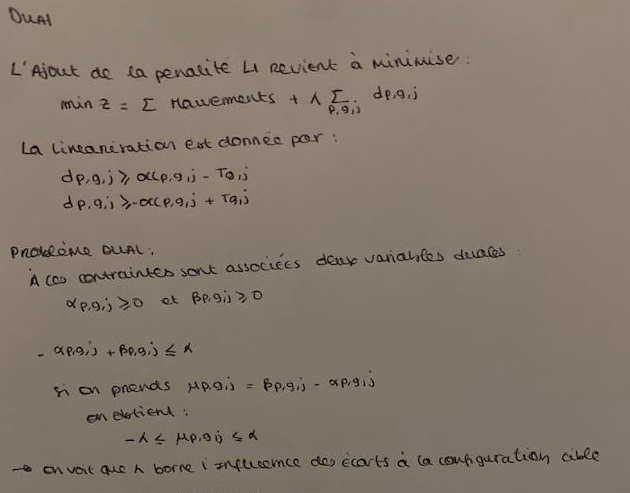

QUESTION 5 : ON determine la solution avec lamda=100

In [11]:
status = prob.solve()
print(pulp.LpStatus[status])

if pulp.LpStatus[status] == "Optimal":
    print(round(pulp.value(prob.objective), 2))
    for p in all_phases_inc_0:
        penalty_val = sum(pulp.value(diff_vars[p][g][j]) for g in groups for j in offices)
        print(p, round(penalty_val))
        if p > 0:
            for g in groups:
                for i in offices:
                    for j in offices:
                        val = pulp.value(move_vars[p][g][i][j])
                        if val is not None and val > 0.5:
                            print(p, g, i, j, int(round(val)))


Optimal
5238.0
0 20
1 8
1 M B1 E1 1
1 M D2 D1 1
1 M D3 E2 1
1 O B1 E2 1
1 O B3 E1 1
1 T B3 D3 1
1 T C1 D2 2
1 S B2 C1 2
2 8
2 M D1 B2 1
2 M D3 B1 1
2 M E1 B2 1
2 M E2 B3 1
2 T D1 E2 1
2 T D2 B1 1
2 T D2 E1 1
2 T D3 B3 1
3 8
3 T B1 D2 1
3 T B3 D2 1
3 T E1 D3 1
3 T E2 D1 1
3 S C1 E1 1
3 S C1 E2 1
3 S C2 D1 1
3 S C2 D3 1
4 8
4 P A1 B1 1
4 P A1 D3 1
4 P A2 B3 1
4 P A2 D1 1
4 S D1 C1 1
4 S D3 C1 1
4 S E1 C2 1
4 S E2 C2 1
5 0
5 P B1 A2 1
5 P B3 A1 1
5 P D1 A2 1
5 P D3 A1 1


In [12]:
status = prob.solve()

if pulp.LpStatus[status] == "Optimal":
    min_moves_physiques = sum(
        pulp.value(move_vars[p][g][i][j])
        for p in phases
        for g in groups
        for i in offices
        for j in offices
        if i != j
    )
    print(int(round(min_moves_physiques)))


38


OBSERVATION : LE NOMBRE MINIMALE DE DEPLACEMENT SEMBLE ETRE 38

Le LP semble réalisable 

oui il y a une difference sur le nombre de deplacement trouvé en partie 1 : mais ca reste mineur : 7 deplacement quand lambda = 100, moins quand lamda <100


POUR LE DUAL 

In [ ]:
if pulp.LpStatus[status] == "Optimal":
    for name, constraint in prob.constraints.items():
        pi = constraint.pi
        if pi is not None and abs(pi) > 1e-5:
            print(name, round(pi, 4))


PARTIE 3 : ON ESSAIE DE MODELISER LE PROGRAMME SOUS FORME SEMI-DEFINIE-POSITIVE 





QUESTION 6 :  Form asemidefinite programming model of the problem based on the relaxation idea (2)

ici je vois le probleme sous cette forme : 

ici je devais faire un SDP liée au placement de chaque individu (de 1 a 18) plutot que le placement d'un membre d'un groupe comme pour le lp 

j'ai implementer ce type de SDP avec des variables associées à la phase, l'individu et le bureau, on avait alors N=5x12x18 =1080, ce qui provoquer une matrice U enorme, calcul excessivement long : j'ai attendu 2 heures sans aucune solutions affiché.

"J'essaie alors de changer de stratégie avec la question 3, partie 1 : je sais que les S et P sont destinés à rester entre eux. De même, il y a déjà des couples M et T formés en phase initiale. Et donc, pour alléger la taille de N et avoir une approximation des déplacements avec une forme SDP, je décide de considérer les deux P de A1 (en phase initiale) comme un seul groupe se déplaçant à deux, même chose pour les deux P de A2, les deux S de C2 et B2, le couple T en C1 et le couple M en D3 : on passe alors d’une étude sur 18 individus à une étude sur 12 groupes (formés d’1 ou 2 membres). Cela rend N assez petit pour fournir une solution avec Python en moins de 10 minutes environ.

Ainsi, la variable "e" sera un groupe et "se" le nombre d’individus dans ce groupe."

A noté avec ce système de groupe : la contrainte qui oblige les etudiants(S) et la presidence(P) à avoir des bureaux commun est deja respecter (on a deux groupe de S et deux groupes de P) on peu donc se permettre de ne plus utiliser ces deux contraintes pour la suite 

pour eviter que N soit trop grand je decide egalement de ne pas considerer les deplacement en phases initiales et de commencer en phase 1 : la phase zero est utile uniqueme pour fixer les places des groupe e a la phase initiale 

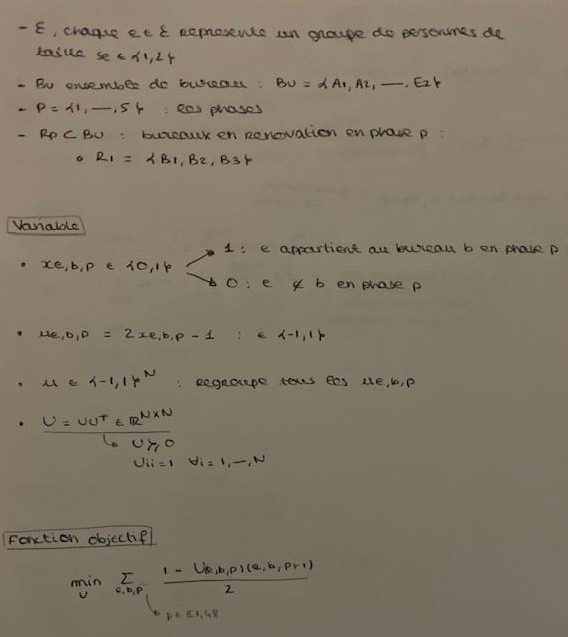

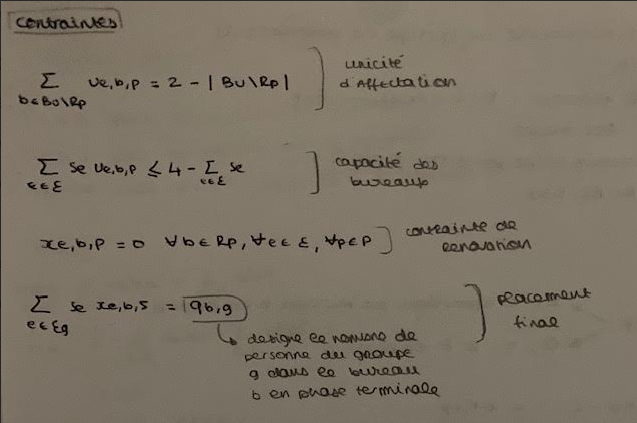

fonction objectif : ici sert a limiter le nombre de deplacement

LES KKT CONDITIONS : 

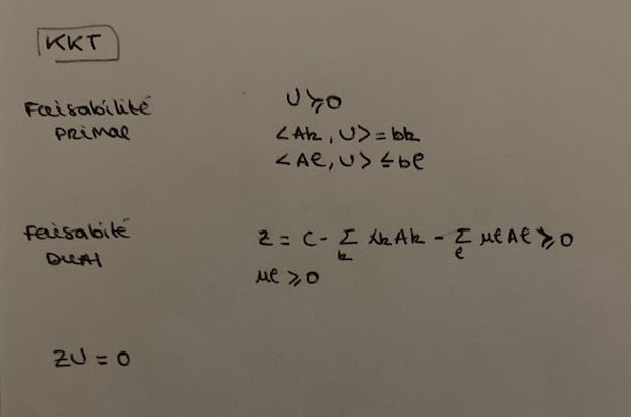

LE DUAL ASSOCIE

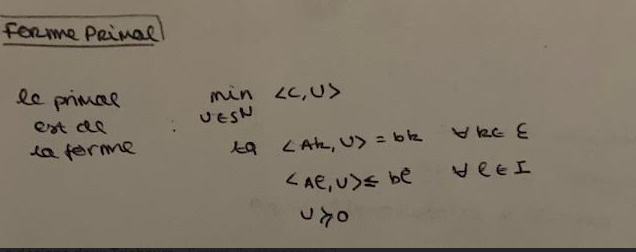

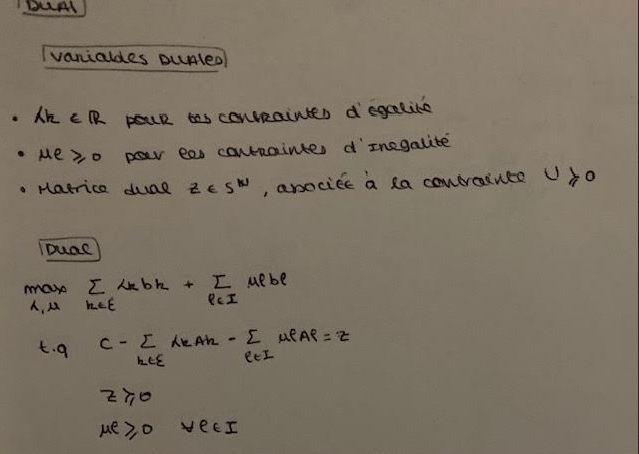

QUESTION 7 : ON MET LE SDP Programm sous forme python 

In [22]:
import cvxpy as cp
import numpy as np

#on forme les groupes e, leur nombre et le placement initiale 
en = [
    {'id': 0, 'size': 2, 'type': 'P', 'start': 'A1'},
    {'id': 1, 'size': 2, 'type': 'P', 'start': 'A2'},
    {'id': 2, 'size': 1, 'type': 'O', 'start': 'B1'}, 
    {'id': 3, 'size': 1, 'type': 'M', 'start': 'B1'}, 
    {'id': 4, 'size': 2, 'type': 'S', 'start': 'B2'},
    {'id': 5, 'size': 1, 'type': 'O', 'start': 'B3'}, 
    {'id': 6, 'size': 1, 'type': 'T', 'start': 'B3'}, 
    {'id': 7, 'size': 2, 'type': 'T', 'start': 'C1'},
    {'id': 8, 'size': 2, 'type': 'S', 'start': 'C2'},
    {'id': 9, 'size': 1, 'type': 'T', 'start': 'D1'},
    {'id': 10, 'size': 1, 'type': 'M', 'start': 'D2'},
    {'id': 11, 'size': 2, 'type': 'M', 'start': 'D3'}
]

offices = ['A1','A2','B1','B2','B3','C1','C2','D1','D2','D3','E1','E2']
renovation = {1:['B1','B2','B3'],2:['D1','D2','D3'],3:['C1','C2'],4:['A1','A2'],5:[]}
#phase de 1 à 5 : la phase zero est utile uniqueme pour fixer les places des groupe e a la phase initiale 
phases = [1,2,3,4,5]

#ici on creer le triplet e,bureau,p hase
var_map = {}
idx = 1

for p in phases:
    for ent in en:
        for off in offices:
            #on ne considere pas le cas ou le bureau est en renovation
            if off not in renovation[p]:
                var_map[(ent['id'], off, p)] = idx
                idx += 1

N = idx
U = cp.Variable((N, N), PSD=True) #contraintes matrice U 
constraints = [cp.diag(U) == 1, U[0, 0] == 1] #contraintes matrice U 
obj_fct = 0

for p in phases:
    open_offices = [o for o in offices if o not in renovation[p]]
    
    #boucles pour les contraintes 
    for ent in en:
        e_idx = [var_map[(ent['id'], o, p)] for o in open_offices if (ent['id'], o, p) in var_map]
        constraints += [cp.sum([U[0,i] for i in e_idx]) == 2 - len(e_idx)]

    for off in open_offices:
        w = 0
        s = 0
        for ent in en:
            if (ent['id'], off, p) in var_map:
                u = var_map[(ent['id'], off, p)]
                w += ent['size'] * U[0,u]
                s += ent['size']
        constraints += [w <= 4 - s]

final_etats = {
    'A1': ('P', 2), 'A2': ('P', 2),
    'B1': ('M', 1), 'B2': ('M', 2), 'B3': ('M', 1),
    'C1': ('S', 2), 'C2': ('S', 2),
    'D1': ('T', 1), 'D2': ('T', 2), 'D3': ('T', 1),
    'E1': ('O', 1), 'E2': ('O', 1)
}

#boucles pour placement final 
for off,(g,q) in final_etats.items():
    idxs = [var_map[(e['id'],off,5)] for e in en if e['type']==g and (e['id'],off,5) in var_map]
    sizes = [e['size'] for e in en if e['type']==g and (e['id'],off,5) in var_map]
    constraints += [cp.sum([sizes[i]*U[0,idxs[i]] for i in range(len(idxs))]) == 2*q - sum(sizes)]

#pour limiter le nombre de déplacement// fonction objectif...
for ent in en:
    start = ent['start']
    if start not in renovation[1]:
        if (ent['id'], start, 1) in var_map:
            u = var_map[(ent['id'], start, 1)]
            obj_fct += 0.5 * (1 - U[0,u])
    else:
        obj_fct += 1

for ent in en:
    for p in range(1,5):
        for off in offices:
            if (ent['id'],off,p) in var_map and (ent['id'],off,p+1) in var_map:
                i1 = var_map[(ent['id'],off,p)]
                i2 = var_map[(ent['id'],off,p+1)]
                obj_fct += 0.5 * (1 - U[i1,i2])

prob = cp.Problem(cp.Minimize(obj_fct), constraints)
prob.solve(solver=cp.SCS, eps=1e-3)


np.float64(7.640577634067114)

In [23]:
print(U.value)
#matrice qui ressort ducoup de toute la SDP precedente 

[[ 1.00000575  0.75693091 -1.00711555 ... -1.00328047 -1.00269856
  -1.00269856]
 [ 0.75693091  0.99999994 -0.74744429 ... -0.74405282 -0.73735803
  -0.73735803]
 [-1.00711555 -0.74744429  0.9999993  ...  0.99781339  0.99735591
   0.99735591]
 ...
 [-1.00328047 -0.74405282  0.99781339 ...  0.99999765  0.99632316
   0.99632316]
 [-1.00269856 -0.73735803  0.99735591 ...  0.99632316  0.99999733
   0.99622974]
 [-1.00269856 -0.73735803  0.99735591 ...  0.99632316  0.99622974
   0.99999733]]


Pour la quetsion 8 : Apply the randomized approach seen in class to obtain an integer solution for the
allocation problem. Is the resulting allocation feasible? Does it seem optimal?

À partir de la solution du programme SDP obtenue à la question 7, on applique la méthode de randomisation de Goemans–Williamson vue en cours afin d’obtenir une solution entière. Comme la matrice U est semi-définie positive, on la factorise sous la forme U=VV⊤. On tire ensuite un vecteur aléatoire gaussien et on projette les vecteurs associés aux variables afin d’obtenir une solution binaire."

In [ ]:
# 1. Décomposition spectrale 
eigvals, eigvecs = np.linalg.eigh(U.value)
eigvals[eigvals < 0] = 0
V = eigvecs @ np.diag(np.sqrt(eigvals))

# 2. Tirage aléatoire gaussien
r = np.random.randn(V.shape[1])

# 3. Solution binaire 
projections = V @ r
u_rand = np.sign(projections) * np.sign(projections[0]) 

x_rand = (1 + u_rand) / 2


print(f"Nombre total d'affectations actives : {int(np.sum(x_rand))}")
print("\nExemples d'affectations actives (entité, bureau, phase) :")
count = 0
for key, idx in var_map.items():
    if x_rand[idx] > 0.5:
        print(key)
        count += 1
    if count >= 20: break

Nombre total d'affectations actives : 31

Exemples d'affectations actives (entité, bureau, phase) :
(0, 'A1', 1)
(1, 'A2', 1)
(5, 'E2', 1)
(7, 'C1', 1)
(8, 'C2', 1)
(9, 'D1', 1)
(10, 'D2', 1)
(11, 'D3', 1)
(0, 'A1', 2)
(1, 'A2', 2)
(5, 'E2', 2)
(7, 'C1', 2)
(8, 'C2', 2)
(11, 'B1', 2)
(11, 'B2', 2)
(0, 'A1', 3)
(1, 'A2', 3)
(5, 'E2', 3)
(11, 'B1', 3)
(11, 'B2', 3)


Après la randomisation, la solution entière obtenue ne respecte pas toutes les contraintes du problème, notamment l’unicité d’affectation par entité et par phase. Cela est attendu, car la procédure de randomisation ne garantit pas le respect strict des contraintes combinatoires. Cette étape permet néanmoins d’obtenir une allocation entière à partir de la relaxation SDP.

Est-elle admissible (feasible) ? Non l'allocation obtenue présente des violations d'unicité (certaines entités n'ont pas de bureau ou en ont plusieurs) exemple 11 B2 et B1 en meme temps en phase 3 

Semble-t-elle optimale ? Non, car une solution non-admissible ne peut pas être considérée comme optimale. 